<a href="https://colab.research.google.com/github/MBaroonian/Mbaroonian.github.io/blob/main/Machine_learning_Project_after_last_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

beta_true = 0.3
gamma_true = 0.1
R0_true = beta_true / gamma_true

t_tensor = torch.linspace(0, 10, 100).to(device)
y0 = torch.tensor([0.99, 0.01, 0.0], dtype=torch.float32).to(device)

def sir_derivatives(y, beta, gamma):
    S, I, R = y
    return torch.stack([
        -beta*S*I,
        beta*S*I - gamma*I,
        gamma*I
    ])

def rk4_step(y, dt, beta, gamma):
    k1 = sir_derivatives(y, beta, gamma)
    k2 = sir_derivatives(y + dt/2*k1, beta, gamma)
    k3 = sir_derivatives(y + dt/2*k2, beta, gamma)
    k4 = sir_derivatives(y + dt*k3, beta, gamma)

    y_next = y + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
    y_next = torch.clamp(y_next, 1e-6, 1.0)
    y_next = y_next / y_next.sum()
    return y_next

def simulate_sir(y0, t, beta, gamma):
    y = y0
    traj = [y]
    for i in range(len(t)-1):
        dt = t[i+1] - t[i]
        y = rk4_step(y, dt, beta, gamma)
        traj.append(y)
    return torch.stack(traj)

def rmse(a, b):
    return torch.sqrt(torch.mean((a - b)**2))

Device: cpu


In [2]:
def generate_data():
    with torch.no_grad():
        traj = simulate_sir(y0, t_tensor, beta_true, gamma_true)

    I_true = traj[:,1]
    I_noisy = torch.clamp(I_true + 0.02*torch.randn_like(I_true), 0, 1)

    return traj, I_true, I_noisy

In [3]:
def classical_fit(I_data):

    beta_vals = np.linspace(0.05, 0.6, 40)
    gamma_vals = np.linspace(0.05, 0.4, 40)

    best_loss = 1e9
    best_b, best_g = None, None

    with torch.no_grad():
        for b in beta_vals:
            for g in gamma_vals:
                traj = simulate_sir(y0, t_tensor, b, g)
                loss = rmse(traj[:,1], I_data).item()

                if loss < best_loss:
                    best_loss = loss
                    best_b, best_g = b, g

    return float(best_b), float(best_g)

In [4]:
class NeuralODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor(0.2))
        self.gamma = nn.Parameter(torch.tensor(0.2))

    def forward(self, y0):
        b = torch.nn.functional.softplus(self.beta)
        g = torch.nn.functional.softplus(self.gamma)
        traj = simulate_sir(y0, t_tensor, b, g)
        return traj, b, g

def train_node(I_data, epochs=500):
    model = NeuralODE().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)

    for _ in range(epochs):
        opt.zero_grad()
        traj, b, g = model(y0)
        loss = rmse(traj[:,1], I_data)
        loss.backward()
        opt.step()

    return float(b.item()), float(g.item())

In [5]:
def generate_multi_data():

    y0_list = [
        torch.tensor([0.99,0.01,0],dtype=torch.float32).to(device),
        torch.tensor([0.97,0.03,0],dtype=torch.float32).to(device),
        torch.tensor([0.95,0.05,0],dtype=torch.float32).to(device)
    ]

    datasets = []

    for y0_i in y0_list:
        with torch.no_grad():
            traj = simulate_sir(y0_i, t_tensor, beta_true, gamma_true)

        I = traj[:,1]
        I_noisy = torch.clamp(I + 0.02*torch.randn_like(I),0,1)

        datasets.append((y0_i, I_noisy))

    return datasets


def train_node_multi(datasets, epochs=300):

    model = NeuralODE().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)

    for _ in range(epochs):
        opt.zero_grad()
        loss = 0

        for y0_i, I_i in datasets:
            traj, b, g = model(y0_i)
            loss += rmse(traj[:,1], I_i)

        loss.backward()
        opt.step()

    return float(b.item()), float(g.item())

In [6]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,3)
        )
        self.beta = nn.Parameter(torch.tensor(0.2))
        self.gamma = nn.Parameter(torch.tensor(0.2))

    def forward(self, t):
        raw = self.net(t)

        S = torch.sigmoid(raw[:,0])
        I = torch.sigmoid(raw[:,1])
        R = torch.sigmoid(raw[:,2])

        total = S+I+R+1e-8
        return S/total, I/total, R/total


def train_pinn(I_data, epochs=300):

    model = PINN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    t_in = t_tensor.unsqueeze(1)

    for _ in range(epochs):
        opt.zero_grad()
        t_in.requires_grad_(True)

        S,I,R = model(t_in)
        b = torch.relu(model.beta)
        g = torch.relu(model.gamma)

        dS = torch.autograd.grad(S.sum(), t_in, create_graph=True)[0]
        dI = torch.autograd.grad(I.sum(), t_in, create_graph=True)[0]
        dR = torch.autograd.grad(R.sum(), t_in, create_graph=True)[0]

        phys = ((dS + b*S*I)**2).mean() + \
               ((dI - (b*S*I - g*I))**2).mean() + \
               ((dR - g*I)**2).mean()

        data = ((I - I_data)**2).mean()
        ic = ((S[0]-y0[0])**2 + (I[0]-y0[1])**2 + (R[0]-y0[2])**2)

        loss = data + 0.1*phys + 10*ic
        loss.backward()
        opt.step()

    return float(torch.relu(model.beta).item()), float(torch.relu(model.gamma).item())

In [7]:
def monte_carlo(runs=5):

    results = {
        "classical": [],
        "node_single": [],
        "node_multi": [],
        "pinn": []
    }

    for i in range(runs):

        _, _, I_data = generate_data()

        results["classical"].append(classical_fit(I_data))
        results["node_single"].append(train_node(I_data))
        results["node_multi"].append(train_node_multi(generate_multi_data()))
        results["pinn"].append(train_pinn(I_data))

        print(f"Run {i+1}/{runs}")

    return results

In [8]:
def compute_metrics(results):

    summary = {}

    for method, vals in results.items():

        b_err, g_err, r0_err = [], [], []

        for b, g in vals:
            b_err.append(abs(b - beta_true))
            g_err.append(abs(g - gamma_true))
            r0_err.append(abs((b/g) - R0_true))

        summary[method] = {
            "beta_mean": np.mean(b_err),
            "gamma_mean": np.mean(g_err),
            "R0_mean": np.mean(r0_err),
            "beta_std": np.std(b_err)
        }

    return summary

In [9]:
def plot_results(results):

    classical = [b for b,_ in results["classical"]]
    node_s   = [b for b,_ in results["node_single"]]
    node_m   = [b for b,_ in results["node_multi"]]
    pinn     = [b for b,_ in results["pinn"]]

    # Histogram
    plt.figure()
    plt.hist(classical, alpha=0.5, label="Classical")
    plt.hist(node_s, alpha=0.5, label="NODE single")
    plt.hist(node_m, alpha=0.5, label="NODE multi")
    plt.hist(pinn, alpha=0.5, label="PINN")
    plt.axvline(beta_true, linestyle='--', color='black')
    plt.legend()
    plt.title("Monte Carlo Histogram")
    plt.show()

    # Boxplot
    plt.figure()
    plt.boxplot([classical, node_s, node_m, pinn],
                labels=["Classical","NODE single","NODE multi","PINN"])
    plt.axhline(beta_true, linestyle='--')
    plt.title("Monte Carlo Boxplot")
    plt.show()

Run 1/5
Run 2/5
Run 3/5
Run 4/5
Run 5/5
{'classical': {'beta_mean': np.float64(0.13897435897435897), 'gamma_mean': np.float64(0.12820512820512822), 'R0_mean': np.float64(1.314176301015043), 'beta_std': np.float64(0.10090843129089079)}, 'node_single': {'beta_mean': np.float64(0.5291954398155212), 'gamma_mean': np.float64(0.4716109991073608), 'R0_mean': np.float64(1.5473797038274668), 'beta_std': np.float64(0.05519215879791713)}, 'node_multi': {'beta_mean': np.float64(0.19263168573379516), 'gamma_mean': np.float64(0.14840402603149414), 'R0_mean': np.float64(1.016409274334947), 'beta_std': np.float64(0.008673166339083235)}, 'pinn': {'beta_mean': np.float64(0.04064958930015564), 'gamma_mean': np.float64(0.08097259104251861), 'R0_mean': np.float64(1.1865509273704073), 'beta_std': np.float64(0.025335678076774892)}}


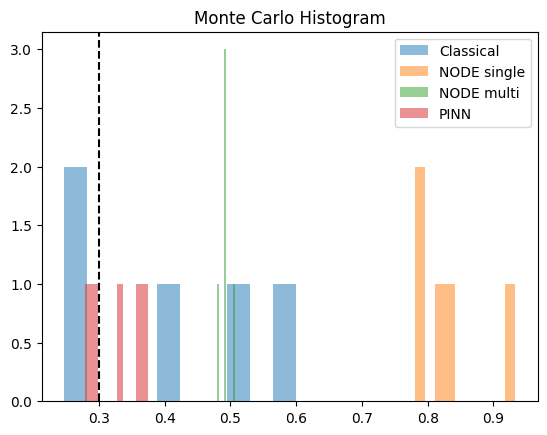

/tmp/ipykernel_7004/2268462878.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([classical, node_s, node_m, pinn],


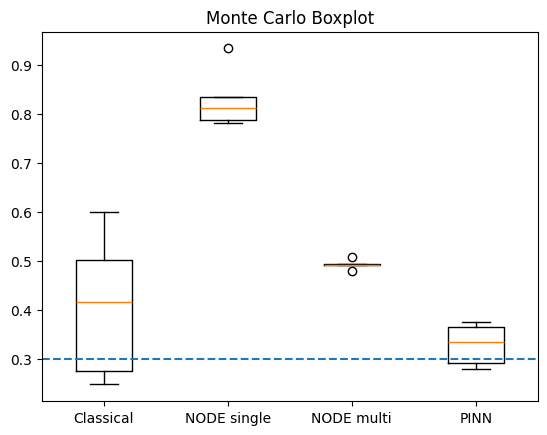

In [10]:
results = monte_carlo(5)
summary = compute_metrics(results)

print(summary)

plot_results(results)

In [11]:
# ============================================
# CLEAN PRINT (TABLE STYLE)
# ============================================

def print_summary(summary):
    print("\n=== MONTE CARLO SUMMARY ===\n")
    print(f"{'Method':<20} {'Beta Err':<12} {'Gamma Err':<12} {'R0 Err':<12} {'Beta Std':<12}")
    print("-"*70)

    for method, vals in summary.items():
        print(f"{method:<20} "
              f"{vals['beta_mean']:<12.4f} "
              f"{vals['gamma_mean']:<12.4f} "
              f"{vals['R0_mean']:<12.4f} "
              f"{vals['beta_std']:<12.4f}")

print_summary(summary)


=== MONTE CARLO SUMMARY ===

Method               Beta Err     Gamma Err    R0 Err       Beta Std    
----------------------------------------------------------------------
classical            0.1390       0.1282       1.3142       0.1009      
node_single          0.5292       0.4716       1.5474       0.0552      
node_multi           0.1926       0.1484       1.0164       0.0087      
pinn                 0.0406       0.0810       1.1866       0.0253      


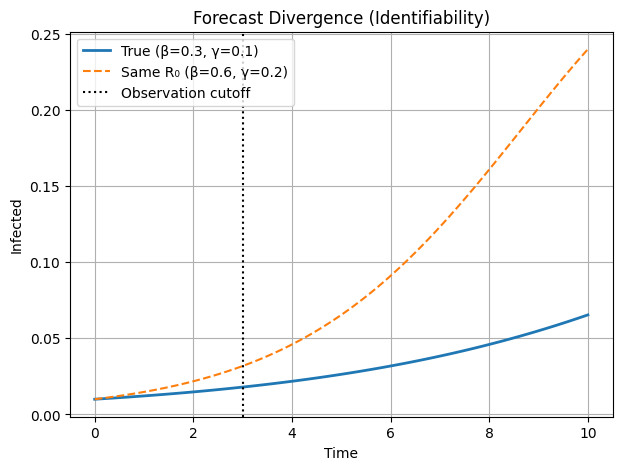

In [12]:
# ============================================
# FORECAST DIVERGENCE
# ============================================

def plot_forecast_divergence():

    # Same R0, different beta/gamma
    b1, g1 = 0.3, 0.1          # true
    b2, g2 = 0.6, 0.2          # same R0 = 3

    traj1 = simulate_sir(y0, t_tensor, b1, g1)
    traj2 = simulate_sir(y0, t_tensor, b2, g2)

    plt.figure(figsize=(7,5))

    plt.plot(t_tensor.cpu(), traj1[:,1].cpu(), label="True (β=0.3, γ=0.1)", linewidth=2)
    plt.plot(t_tensor.cpu(), traj2[:,1].cpu(), '--', label="Same R₀ (β=0.6, γ=0.2)")

    plt.axvline(3, linestyle=':', color='black', label="Observation cutoff")

    plt.xlabel("Time")
    plt.ylabel("Infected")
    plt.title("Forecast Divergence (Identifiability)")
    plt.legend()
    plt.grid()
    plt.show()

plot_forecast_divergence()

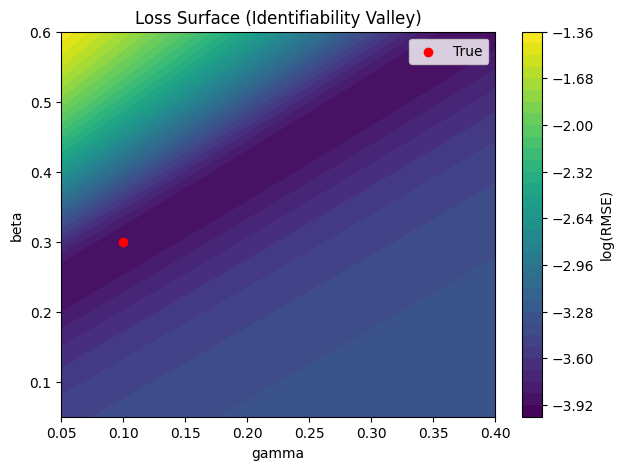

In [13]:
# ============================================
# LOSS SURFACE
# ============================================

def plot_loss_surface(I_data):

    beta_vals = np.linspace(0.05, 0.6, 40)
    gamma_vals = np.linspace(0.05, 0.4, 40)

    L = np.zeros((len(beta_vals), len(gamma_vals)))

    with torch.no_grad():
        for i, b in enumerate(beta_vals):
            for j, g in enumerate(gamma_vals):
                traj = simulate_sir(y0, t_tensor, b, g)
                L[i,j] = rmse(traj[:,1], I_data).item()

    plt.figure(figsize=(7,5))

    plt.contourf(gamma_vals, beta_vals, np.log(L + 1e-8), levels=40)
    plt.colorbar(label="log(RMSE)")

    plt.scatter(gamma_true, beta_true, color='red', label="True")

    plt.xlabel("gamma")
    plt.ylabel("beta")
    plt.title("Loss Surface (Identifiability Valley)")
    plt.legend()
    plt.show()


# Run it
_, _, I_data = generate_data()
plot_loss_surface(I_data)

In [14]:
# ============================================
# RAW PARAMETER VALUES
# ============================================

for method, vals in results.items():
    print(f"\n{method}:")
    for i, (b,g) in enumerate(vals):
        print(f"Run {i+1}: beta={b:.4f}, gamma={g:.4f}")


classical:
Run 1: beta=0.5013, gamma=0.2833
Run 2: beta=0.2756, gamma=0.0679
Run 3: beta=0.4167, gamma=0.2026
Run 4: beta=0.2474, gamma=0.0500
Run 5: beta=0.6000, gamma=0.3731

node_single:
Run 1: beta=0.8336, gamma=0.5761
Run 2: beta=0.7802, gamma=0.5260
Run 3: beta=0.8111, gamma=0.5533
Run 4: beta=0.7881, gamma=0.5407
Run 5: beta=0.9331, gamma=0.6619

node_multi:
Run 1: beta=0.4928, gamma=0.2478
Run 2: beta=0.4914, gamma=0.2481
Run 3: beta=0.4920, gamma=0.2478
Run 4: beta=0.5072, gamma=0.2591
Run 5: beta=0.4799, gamma=0.2391

pinn:
Run 1: beta=0.2796, gamma=0.1738
Run 2: beta=0.3752, gamma=0.2021
Run 3: beta=0.3646, gamma=0.1793
Run 4: beta=0.3339, gamma=0.1806
Run 5: beta=0.2908, gamma=0.1691
